<a href="https://colab.research.google.com/github/swapna0727-source/AI/blob/main/Copy_of_RandomForest.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier


In [ ]:
data = load_breast_cancer()
X, y = data.data, data.target

In [ ]:
# Split into training and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [ ]:
forest = RandomForestClassifier(n_estimators=100, random_state=42)
forest.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [ ]:
# Evaluate accuracy
print("Train accuracy:", forest.score(X_train, y_train))
print("Test accuracy:", forest.score(X_test, y_test))

Train accuracy: 1.0
Test accuracy: 0.956140350877193


In [ ]:
forest = RandomForestClassifier(n_estimators=100, max_depth = 4,  random_state=42)
forest.fit(X_train, y_train)

RandomForestClassifier(max_depth=4, random_state=42)

In [ ]:
# Evaluate accuracy
print("Train accuracy:", forest.score(X_train, y_train))
print("Test accuracy:", forest.score(X_test, y_test))

Train accuracy: 0.9934065934065934
Test accuracy: 0.956140350877193


In [ ]:
y_pred = forest.predict(X_test)

In [ ]:
y_pred

array([0, 1, 0, 0, 0, 1, 1, 0, 0, 0, 1, 0, 1, 0, 0, 1, 1, 1, 1, 1, 0, 0,
       1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 0,
       0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 0, 1,
       1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 1,
       1, 1, 1, 1, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 1, 0, 1, 0,
       1, 0, 1, 1])

In [ ]:
for n in [1, 5, 10, 50, 100, 200]:
    f = RandomForestClassifier(n_estimators=n, random_state=42)
    f.fit(X_train, y_train)

    print(f"n_estimators={n}: Test accuracy = {f.score(X_test, y_test):.4f}")

n_estimators=1: Test accuracy = 0.9474
n_estimators=5: Test accuracy = 0.9386
n_estimators=10: Test accuracy = 0.9386
n_estimators=50: Test accuracy = 0.9561
n_estimators=100: Test accuracy = 0.9561
n_estimators=200: Test accuracy = 0.9561


In [ ]:
for n in [3,4,5,6,7]:
    f = RandomForestClassifier(n_estimators=50, max_depth = n ,random_state=42)
    f.fit(X_train, y_train)

    print(f"max_depth={n}: Test accuracy = {f.score(X_test, y_test):.4f}")

max_depth=3: Test accuracy = 0.9474
max_depth=4: Test accuracy = 0.9561
max_depth=5: Test accuracy = 0.9561
max_depth=6: Test accuracy = 0.9561
max_depth=7: Test accuracy = 0.9561


In [ ]:
for n in [3,4,5,6,7]:
    f = RandomForestClassifier(n_estimators=50, max_depth = 4 , max_features = n, random_state=42)
    f.fit(X_train, y_train)

    print(f"max_features={n}: Test accuracy = {f.score(X_test, y_test):.4f}")

max_features=3: Test accuracy = 0.9561
max_features=4: Test accuracy = 0.9561
max_features=5: Test accuracy = 0.9561
max_features=6: Test accuracy = 0.9474
max_features=7: Test accuracy = 0.9561


In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

single_tree = DecisionTreeClassifier(max_depth=4, random_state=42)
single_tree.fit(X_train, y_train)

best_forest = RandomForestClassifier(
    n_estimators=100,
    max_depth=4,
    random_state=42
)
best_forest.fit(X_train, y_train)

print("Single Tree - Test:", single_tree.score(X_test, y_test))
print("Random Forest - Test:", best_forest.score(X_test, y_test))

Single Tree - Test: 0.9385964912280702
Random Forest - Test: 0.956140350877193


In [ ]:
best_forest.feature_importances_

array([0.07096471, 0.01125813, 0.07530759, 0.04882731, 0.00450043,
       0.01187036, 0.05989565, 0.09693065, 0.00260427, 0.00312947,
       0.01527648, 0.00403624, 0.00814273, 0.03082513, 0.00116775,
       0.00463869, 0.00373833, 0.00223841, 0.00307801, 0.00256168,
       0.10441628, 0.01248145, 0.0716422 , 0.14369311, 0.01120074,
       0.01900773, 0.03428873, 0.12896617, 0.0075576 , 0.00575396])

<Axes: >

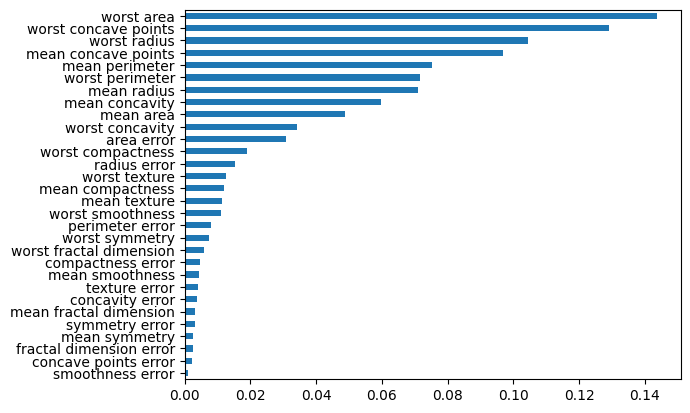

In [ ]:
import pandas as pd
importances = pd.Series(best_forest.feature_importances_, index=data.feature_names)
importances.sort_values().plot(kind="barh")

In [ ]:
import joblib

In [ ]:
joblib.dump(best_forest, "model_forest.pkl")

['model_forest.pkl']

In [ ]:
loaded_model = joblib.load("model_forest.pkl")

In [ ]:
sample = X_test[0].reshape(1, -1)

In [ ]:
sample

array([[1.955e+01, 2.877e+01, 1.336e+02, 1.207e+03, 9.260e-02, 2.063e-01,
        1.784e-01, 1.144e-01, 1.893e-01, 6.232e-02, 8.426e-01, 1.199e+00,
        7.158e+00, 1.064e+02, 6.356e-03, 4.765e-02, 3.863e-02, 1.519e-02,
        1.936e-02, 5.252e-03, 2.505e+01, 3.627e+01, 1.786e+02, 1.926e+03,
        1.281e-01, 5.329e-01, 4.251e-01, 1.941e-01, 2.818e-01, 1.005e-01]])

In [ ]:
y_pred = loaded_model.predict(sample)

In [ ]:
y_pred = loaded_model.predict(sample)


In [ ]:
y_pred

array([0])

In [ ]:
# SIngle model is not good.

In [ ]:
# single test data ? we cannot trust on single data split (test data)